In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [5]:
data = pd.read_csv("C:/Users/e_bab/Documents/4geeks/python-hello/logistic-regression-project-tutorial/bank-marketing-campaign-data.csv", sep = ";")
print(data.head())
print(data.info())
print(data.shape)

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [41]:
print(data.duplicated().sum())
# print(data[data.duplicated])
# print(data.columns.duplicated().sum())
print(data.isnull().sum())

# no null entry 
# 12 duplicated rows


0
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
month             0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
y_n               0
dtype: int64


In [ ]:
# drop duplicate 
data = data.drop_duplicates()
print(data.shape)
print(data.duplicated().sum())
# dropping unimportant columns 
for col in [ "emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed"]:
    print (col, data[col].nunique())

# keep the numericla value from columns 16-21. remove contact, day_of_week, duration   
data = data.drop (columns =["contact", "day_of_week","duration"]) 



print(data.shape)
print(data.head())



(38765, 20)
0
emp.var.rate 10
cons.price.idx 26
cons.conf.idx 26
euribor3m 316
nr.employed 11
(38765, 20)
   age        job  marital    education  default housing loan month  campaign  \
0   56  housemaid  married     basic.4y       no      no   no   may         1   
1   57   services  married  high.school  unknown      no   no   may         1   
2   37   services  married  high.school       no     yes   no   may         1   
3   40     admin.  married     basic.6y       no      no   no   may         1   
4   56   services  married  high.school       no      no  yes   may         1   

   pdays  previous     poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  \
0    999         0  nonexistent           1.1          93.994          -36.4   
1    999         0  nonexistent           1.1          93.994          -36.4   
2    999         0  nonexistent           1.1          93.994          -36.4   
3    999         0  nonexistent           1.1          93.994          -36.4   
4    99

In [ ]:
# testing the factorize for the categorical, other than y column
data["education_n"] = pd.factorize(data["education"])[0]
print(data.head(5))
data = data.drop (columns ="education_n")
print(data.head(2))


   age        job  marital    education  default housing loan month  campaign  \
0   56  housemaid  married     basic.4y       no      no   no   may         1   
1   57   services  married  high.school  unknown      no   no   may         1   
2   37   services  married  high.school       no     yes   no   may         1   
3   40     admin.  married     basic.6y       no      no   no   may         1   
4   56   services  married  high.school       no      no  yes   may         1   

   pdays  previous     poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  \
0    999         0  nonexistent           1.1          93.994          -36.4   
1    999         0  nonexistent           1.1          93.994          -36.4   
2    999         0  nonexistent           1.1          93.994          -36.4   
3    999         0  nonexistent           1.1          93.994          -36.4   
4    999         0  nonexistent           1.1          93.994          -36.4   

   euribor3m  nr.employed   y  y

In [9]:
#categroical to neumerical & split the values

data["y_n"]= pd.factorize(data["y"])[0]

cat_columns = ["job", "marital","education","default","housing","loan","month","poutcome"]
num_columns =["age","campaign","pdays","previous","emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed"]


from sklearn.model_selection import train_test_split
data_fact = pd.get_dummies(data, columns=cat_columns, dtype=int)
print(data_fact.head(2))


x= data_fact.drop(columns = ["y","y_n"])
y= data_fact["y_n"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

x_train.head(3)



   age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
0   56         1    999         0           1.1          93.994   
1   57         1    999         0           1.1          93.994   

   cons.conf.idx  euribor3m  nr.employed   y  ...  month_jul  month_jun  \
0          -36.4      4.857       5191.0  no  ...          0          0   
1          -36.4      4.857       5191.0  no  ...          0          0   

   month_mar  month_may  month_nov  month_oct  month_sep  poutcome_failure  \
0          0          1          0          0          0                 0   
1          0          1          0          0          0                 0   

   poutcome_nonexistent  poutcome_success  
0                     1                 0  
1                     1                 0  

[2 rows x 58 columns]


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,education_n,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_nonexistent,poutcome_success
12348,29,3,999,0,1.4,93.918,-42.7,4.959,5228.1,2,...,1,0,0,0,0,0,0,0,1,0
8565,50,6,999,0,1.4,94.465,-41.8,4.864,5228.1,6,...,0,1,0,0,0,0,0,0,1,0
21424,29,4,999,0,1.4,93.444,-36.1,4.963,5228.1,6,...,0,0,0,0,0,0,0,0,1,0


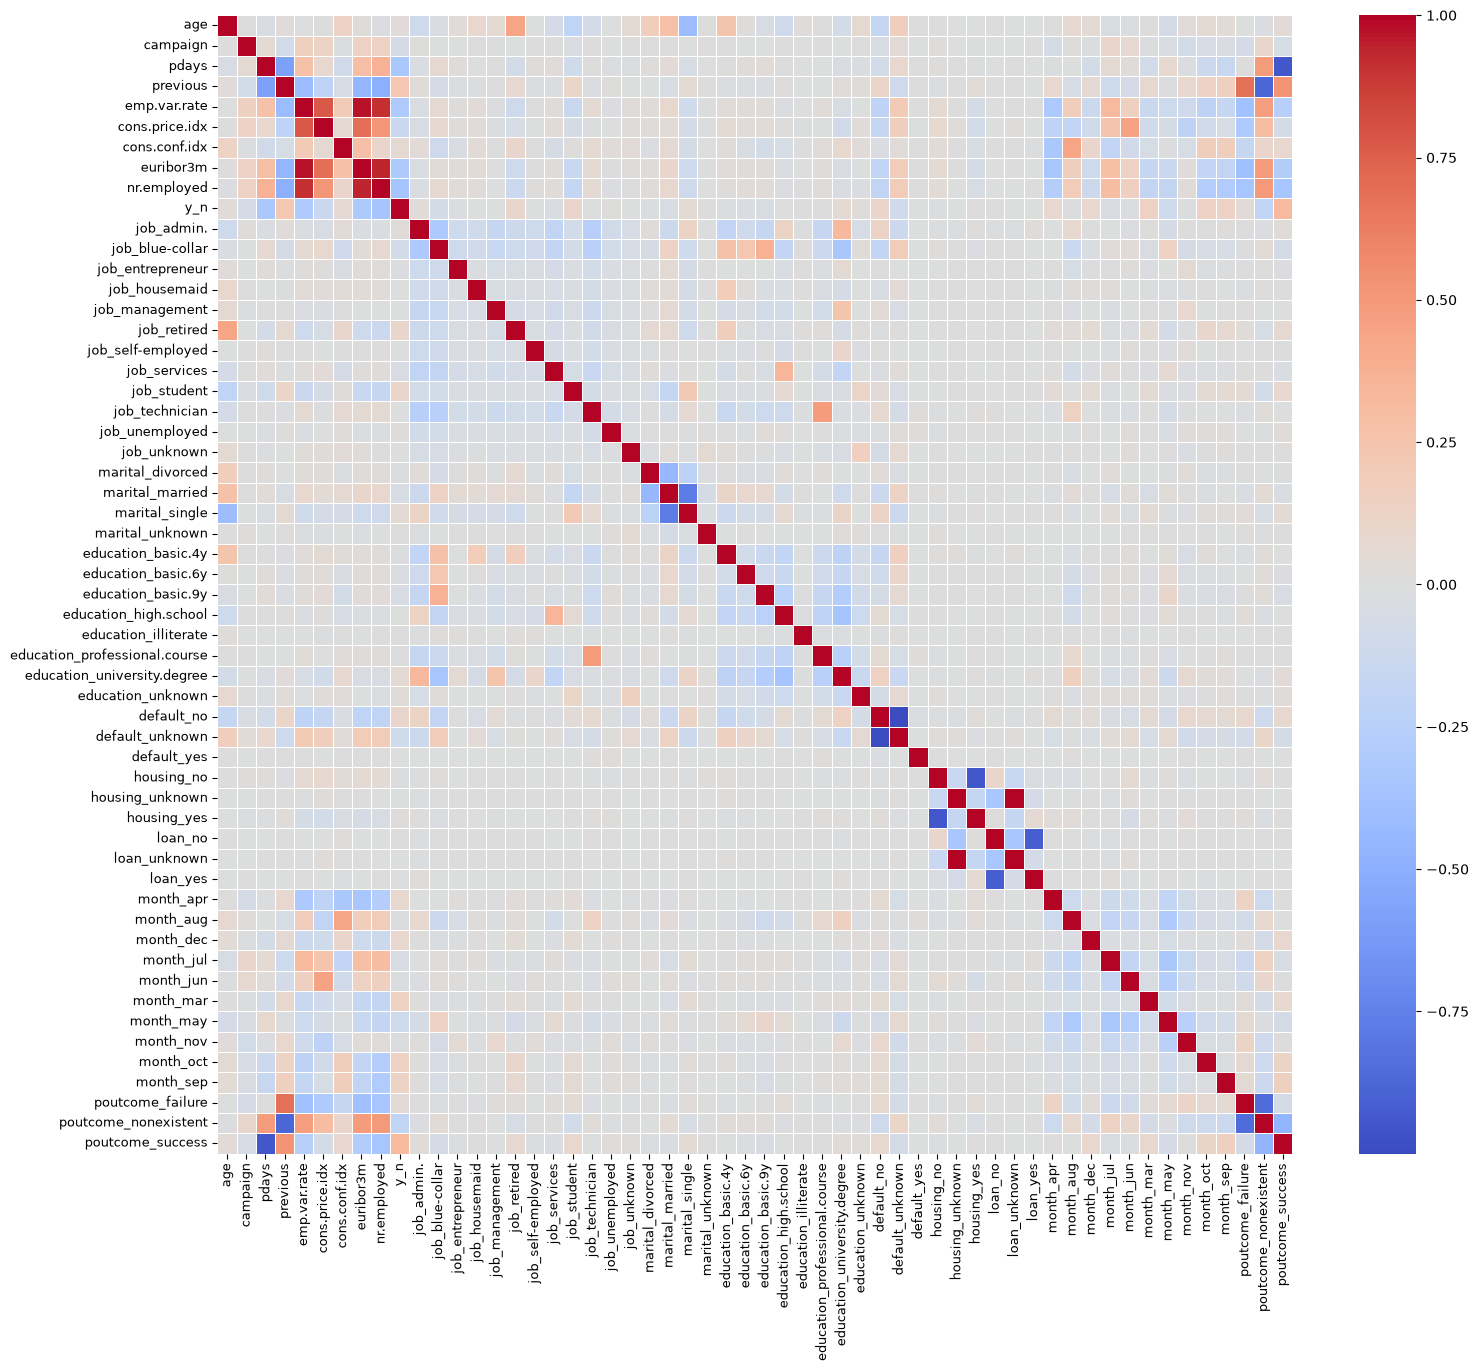

In [40]:
corr_col= cat_columns+num_columns
plt.figure(figsize = (16,14))
sns.heatmap(data_fact.drop(columns = ["y", "education_n"]).corr(), annot=False, linewidths=0.5, fmt=".2f", cmap="coolwarm")

plt.tight_layout()
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(transformers= [("name", StandardScaler(), num_columns)], 
remainder= "passthrough")


x_train_norm = preprocessor.fit_transform(x_train)
x_test_norm= preprocessor.transform(x_test)


x_train_norm = pd.DataFrame(x_train_norm, index= x_train.index, columns= preprocessor.get_feature_names_out())
x_test_norm = pd.DataFrame(x_test_norm, index= x_test.index, columns= preprocessor.get_feature_names_out())

print(x_train_norm.shape)
print(x_test_norm.shape)

print(x_train_norm.head(2))




(32940, 56)
(8236, 56)
       name__age  name__campaign  name__pdays  name__previous  \
12348  -1.058427        0.152155     0.195697       -0.348601   
8565    0.954767        1.229538     0.195697       -0.348601   

       name__emp.var.rate  name__cons.price.idx  name__cons.conf.idx  \
12348            0.838815              0.589534            -0.470932   
8565             0.838815              1.534740            -0.276368   

       name__euribor3m  name__nr.employed  remainder__education_n  ...  \
12348         0.771196           0.843413                     2.0  ...   
8565          0.716413           0.843413                     6.0  ...   

       remainder__month_jul  remainder__month_jun  remainder__month_mar  \
12348                   1.0                   0.0                   0.0   
8565                    0.0                   1.0                   0.0   

       remainder__month_may  remainder__month_nov  remainder__month_oct  \
12348                   0.0             

In [ ]:
## select the best prameter

from sklearn.feature_selection import SelectKBest, f_classif

model_selection= SelectKBest(score_func=f_classif, k= 10)
model_selection.fit(x_train_norm, y_train)

x_train_selec= model_selection.transform(x_train_norm)
x_test_selec=model_selection.transform(x_test_norm)
ix= model_selection.get_support()

x_train_selec=pd.DataFrame(x_train_selec, index= x_train_norm.index, columns = x_train_norm.columns[ix])
x_test_selec=pd.DataFrame(x_test_selec, index= x_test_norm.index, columns = x_test_norm.columns[ix])

print(x_train_selec.head(3))
print(x_train_norm.columns[ix])



       name__pdays  name__previous  name__emp.var.rate  name__cons.price.idx  \
12348     0.195697       -0.348601            0.838815              0.589534   
8565      0.195697       -0.348601            0.838815              1.534740   
21424     0.195697       -0.348601            0.838815             -0.229530   

       name__euribor3m  name__nr.employed  remainder__month_mar  \
12348         0.771196           0.843413                   0.0   
8565          0.716413           0.843413                   0.0   
21424         0.773502           0.843413                   0.0   

       remainder__month_oct  remainder__poutcome_nonexistent  \
12348                   0.0                              1.0   
8565                    0.0                              1.0   
21424                   0.0                              1.0   

       remainder__poutcome_success  
12348                          0.0  
8565                           0.0  
21424                          0.0  
Index

In [ ]:
## initialix=zation, trainign model,, model prediction
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train_selec, y_train)

y_pred = model.predict(x_test_selec)
print(y_pred)

# learn accuracy score
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))



[0 0 0 ... 0 0 0]
0.894851869839728


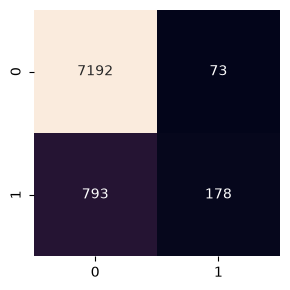

In [ ]:
# constructuing confusion matrix)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

bank_cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(bank_cm)

plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.show()

In [ ]:
## model optimizations --grid search 
from sklearn.model_selection import GridSearchCV

hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 5)
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contro

In [ ]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

grid.fit(x_train_selec, y_train)

print(f"Best hyperparameters: {grid.best_params_}")

Best hyperparameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [ ]:
model_grid = LogisticRegression(penalty = "l1", C = 0.1, solver = "liblinear")
model_grid.fit(x_train_selec, y_train)
y_pred = model_grid.predict(x_test_selec)
print(y_pred)

grid_accuracy = accuracy_score(y_test, y_pred)
print(grid_accuracy)

[0 0 0 ... 0 0 0]
0.8950947061680428
